In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('../data/ratings_Electronics.csv', header = None,  
    names=['user_id', 'product_id', 'rating', 'timestamp'])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

In [3]:
print("Shape:", df.shape)
print("\nFirst 5 rows: ")
df.head()

Shape: (7824482, 4)

First 5 rows: 


,user_id,product_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [4]:
print("=== Dataset Overview ===")
print(f"Total ratings: {len(df):,}")
print(f"Unique users: {df['user_id'].nunique():,}")
print(f"Unique products: {df['product_id'].nunique():,}")
print(f"Rating range: {df['rating'].min()} - {df['rating'].max()}")
print(f"\nRating distribution:")
print(df['rating'].value_counts().sort_index())

=== Dataset Overview ===
Total ratings: 7,824,482
Unique users: 4,201,696
Unique products: 476,002
Rating range: 1.0 - 5.0

Rating distribution:
rating
1.0     901765
2.0     456322
3.0     633073
4.0    1485781
5.0    4347541
Name: count, dtype: int64


In [5]:
# How many ratings does each user typically give?
user_counts = df['user_id'].value_counts()
print("=== User Activity ===")
print(f"Avg ratings per user: {user_counts.mean():.1f}")
print(f"Median ratings per user: {user_counts.median():.1f}")
print(f"Most active user gave: {user_counts.max()} ratings")
print(f"\nUsers who rated only 1 product: {(user_counts == 1).sum():,}")
print(f"That's {(user_counts == 1).sum() / len(user_counts) * 100:.1f}% of all users")

=== User Activity ===
Avg ratings per user: 1.9
Median ratings per user: 1.0
Most active user gave: 520 ratings

Users who rated only 1 product: 2,881,832
That's 68.6% of all users


In [6]:
# Apply 10-core filtering to keep users and products with at least 10 ratings
# Repeat this twice because removing users affects product counts and vice versa

def apply_10_core(df, min_count=10):
    while True:
        # Filter users
        user_counts = df['user_id'].value_counts()
        df = df[df['user_id'].isin(user_counts[user_counts >= min_count].index)]
        
        # Filter products
        product_counts = df['product_id'].value_counts()
        df = df[df['product_id'].isin(product_counts[product_counts >= min_count].index)]
        
        # Stop when nothing more gets removed
        if (user_counts.min() >= min_count) and (product_counts.min() >= min_count):
            break
    return df

df_clean = apply_10_core(df)
print(f"Before: {len(df):,} ratings, {df['user_id'].nunique():,} users, {df['product_id'].nunique():,} products")
print(f"After:  {len(df_clean):,} ratings, {df_clean['user_id'].nunique():,} users, {df_clean['product_id'].nunique():,} products")
print(f"Kept {len(df_clean)/len(df)*100:.1f}% of the data")

Before: 7,824,482 ratings, 4,201,696 users, 476,002 products
After:  347,393 ratings, 20,247 users, 11,589 products
Kept 4.4% of the data


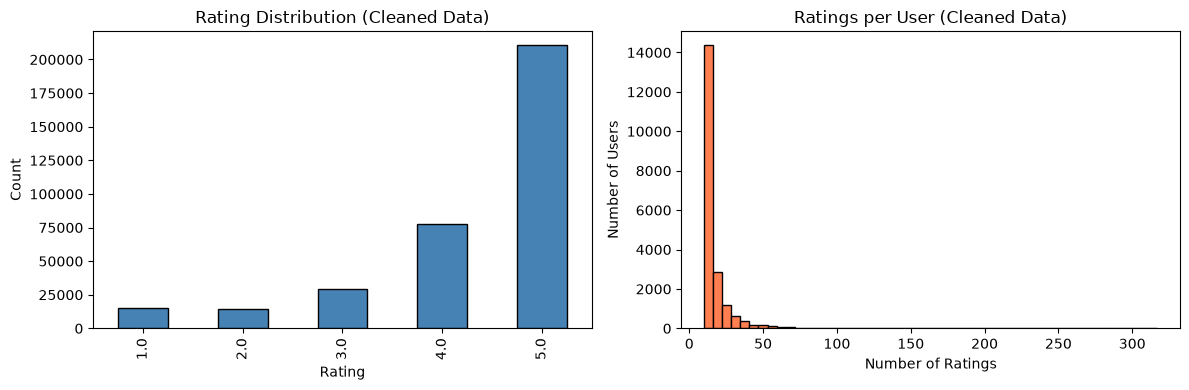

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating distribution
df_clean['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Rating Distribution (Cleaned Data)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Ratings per user distribution
user_counts_clean = df_clean['user_id'].value_counts()
axes[1].hist(user_counts_clean, bins=50, color='coral', edgecolor='black')
axes[1].set_title('Ratings per User (Cleaned Data)')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

In [8]:
# Save cleaned data so we don't have to refilter every time
df_clean.to_csv('../data/ratings_clean.csv', index=False)
print("Saved! File is in your data folder.")

Saved! File is in your data folder.


In [9]:
import sys
if 'collaborative' in sys.modules:
    del sys.modules['collaborative']

sys.path.append('../src')
from collaborative import load_data, build_matrix, train_model, get_recommendations

df_model = load_data()
matrix, df_model, idx_to_product = build_matrix(df_model)

print(f"Matrix shape: {matrix.shape}")
print(f"Training model...")
model = train_model(matrix)
print("Done! Model trained.")

Matrix shape: (11589, 20247)
Training model...


  0%|          | 0/20 [00:00<?, ?it/s]

Done! Model trained.


In [10]:
sample_user = df_model['user_id'].iloc[0]
print(f"Getting recommendations for user: {sample_user}")

already_rated = df_model[df_model['user_id'] == sample_user][['product_id', 'rating']]
print(f"\nProducts they already rated:")
print(already_rated.to_string(index=False))

recs, scores = get_recommendations(model, matrix, df_model, idx_to_product, sample_user, n=5)
print(f"\nTop 5 recommended products:")
for i, (product, score) in enumerate(zip(recs, scores), 1):
    print(f"{i}. Product {product} (score: {score:.3f})")

Getting recommendations for user: A2IDCSC6NVONIZ

Products they already rated:
product_id  rating
0972683275     5.0
B00005T3N3     5.0
B00005V51P     5.0
B00007IFED     5.0
B000V0ETA6     5.0
B001DZJVO2     3.0
B001ID829O     5.0
B0038P1TP4     5.0
B003LLEG00     5.0
B0041Q38NU     5.0
B0047ZFHBG     5.0
B004CADY9I     5.0
B004EFUOY4     5.0
B007IMPMW4     5.0
B007WTAJTO     5.0
B0087Y1XS4     4.0
B00AQM8586     4.0

Top 5 recommended products:
1. Product B00BVQXG1W (score: 0.099)
2. Product B003OBUJIK (score: 0.084)
3. Product B0034L3G8U (score: 0.077)
4. Product B000KA7PD0 (score: 0.076)
5. Product B0021L9BZQ (score: 0.074)


In [13]:
# Get all unique products from our clean dataset
products = df_clean['product_id'].unique()

# Create a simple metadata dataframe
metadata = pd.DataFrame({
    'product_id': products
})

print(f"Total products to create metadata for: {len(metadata)}")
metadata.head()

Total products to create metadata for: 11589


,product_id
0,0972683275
1,1400501466
2,1400532620
3,1400532655
4,140053271X


In [14]:
# Build an item-item similarity matrix
# For each product, find other products that were rated by the same users
from sklearn.metrics.pairwise import cosine_similarity

# Pivot the data — rows are products, columns are users, values are ratings
item_user_matrix = df_clean.pivot_table(
    index='product_id', 
    columns='user_id', 
    values='rating'
).fillna(0)

print(f"Item-user matrix shape: {item_user_matrix.shape}")
print("Computing similarity matrix...")

# Compute cosine similarity between all products
item_similarity = cosine_similarity(item_user_matrix)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

print(f"Similarity matrix shape: {item_similarity_df.shape}")
print("Done!")

Item-user matrix shape: (11589, 20247)
Computing similarity matrix...
Similarity matrix shape: (11589, 11589)
Done!


In [ ]:
import sys
if 'content_based' in sys.modules:
    del sys.modules['content_based']

sys.path.append('../src')
from content_based import build_item_similarity, get_similar_products, get_user_recommendations

print("Building item similarity matrix...")
item_similarity_df = build_item_similarity(df_clean)
print("Done!")

# Test 1 — find products similar to a specific product
test_product = df_clean['product_id'].iloc[0]
print(f"\nFinding products similar to: {test_product}")
similar_products, scores = get_similar_products(item_similarity_df, test_product, n=5)
print("Similar products:")
for i, (p, s) in enumerate(zip(similar_products, scores), 1):
    print(f"{i}. {p} (similarity: {s:.3f})")

# Test 2 — get recommendations for a user
print(f"\nContent-based recommendations for user: {sample_user}")
recs, scores = get_user_recommendations(item_similarity_df, df_clean, sample_user, n=5)
print("Recommended products:")
for i, (p, s) in enumerate(zip(recs, scores), 1):
    print(f"{i}. {p} (similarity: {s:.3f})")

Building item similarity matrix...
Done! ✅

Finding products similar to: 0972683275
Similar products:
1. B002K8H7XS (similarity: 0.100)
2. B004M8SBCK (similarity: 0.087)
3. B001PI09SE (similarity: 0.086)
4. B005D91G38 (similarity: 0.079)
5. B00005T3N3 (similarity: 0.077)

Content-based recommendations for user: A2IDCSC6NVONIZ
Recommended products:
1. B00AAIPT76 (similarity: 0.143)
2. B005FYNSPK (similarity: 0.107)
3. B00DR0PDNE (similarity: 0.107)
4. B0002D017M (similarity: 0.103)
5. B002K8H7XS (similarity: 0.100)


In [16]:
import sys
if 'hybrid' in sys.modules:
    del sys.modules['hybrid']

sys.path.append('../src')
from hybrid import hybrid_recommendations

print(f"Hybrid recommendations for user: {sample_user}")
print("=" * 50)

hybrid_products, hybrid_scores = hybrid_recommendations(
    user_id=sample_user,
    model=model,
    matrix=matrix,
    df_model=df_model,
    idx_to_product=idx_to_product,
    item_similarity_df=item_similarity_df,
    df_clean=df_clean,
    n=5
)

print("\n Hybrid (Layer 1 + Layer 2 combined):")
for i, (p, s) in enumerate(zip(hybrid_products, hybrid_scores), 1):
    print(f"{i}. {p} (score: {s:.3f})")

print("\n Collaborative only (Layer 1):")
for i, p in enumerate(recs[:5], 1):
    print(f"{i}. {p}")

print("\n Content-based only (Layer 2):")
for i, p in enumerate(recs[:5], 1):
    print(f"{i}. {p}")

Hybrid recommendations for user: A2IDCSC6NVONIZ

 Hybrid (Layer 1 + Layer 2 combined):
1. B00BVQXG1W (score: 0.500)
2. B00AAIPT76 (score: 0.500)
3. B003OBUJIK (score: 0.317)
4. B0034L3G8U (score: 0.218)
5. B000KA7PD0 (score: 0.210)

 Collaborative only (Layer 1):
1. B00AAIPT76
2. B005FYNSPK
3. B00DR0PDNE
4. B0002D017M
5. B002K8H7XS

 Content-based only (Layer 2):
1. B00AAIPT76
2. B005FYNSPK
3. B00DR0PDNE
4. B0002D017M
5. B002K8H7XS
